In [1]:
import pandas as pd
import numpy as np
import math

#Visualizing
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'; plt.rcParams['axes.unicode_minus'] = False;
import seaborn as sns; #sns.set_style('whitegrid')

#Time Series Analysis
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#Clustering (+α)
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
from minisom import MiniSom

#Modeling
from keras.models import Sequential
from keras.layers import LSTM
from keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

#System
from ipywidgets import interact
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

In [11]:
df=pd.read_csv('최종_분석데이터.csv',encoding='cp949')
df.tail()

,grid,도시재생사업수,대중교통,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
33446,75000,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33447,75001,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33448,75002,0,2306.248398,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33449,75003,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33450,75004,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563


In [ ]:
# K-Means 모델과 군집 예측값을 생성 
# 클러스터 모델 생성 파라미터는 원할 경우 추가 
model =  KMeans(n_clusters=4, random_state = 200)
                     # 클러스터 갯수 
                     # , n_init=10 
                     # initial centroid를 몇번 샘플링한건지, 데이터가 많으면 많이 돌릴수록안정화된 결과가 나옴 
                     # , max_iter=500 # KMeans를 몇번 반복 수행할건지, K가 큰 경우 1000정도로 높여준다 
                     #random_state = 42 # , algorithm='auto' ) 
 # 생성한 모델로 데이터를 학습시킴 
model.fit(df) # unsupervised learning 
# 결과 값을 변수에 저장 
df['cluster'] = model.fit_predict(df)

In [224]:
df.to_csv('클러스터.csv',encoding='cp949')

In [229]:
df.shape

(741, 18)

In [225]:
df0= df.loc[df['cluster'] == 0]
df0.to_csv('cluster0.csv',encoding='cp949')
df0.shape

(610, 18)

In [226]:
df1= df.loc[df['cluster'] == 1]
df1.to_csv('cluster0.csv',encoding='cp949')
df1.shape

(26, 18)

In [227]:
df2= df.loc[df['cluster'] == 2]
df2.to_csv('cluster0.csv',encoding='cp949')
df2.shape

(4, 18)

In [228]:
df3= df.loc[df['cluster'] == 3]
df3.to_csv('cluster0.csv',encoding='cp949')
df3.shape

(101, 18)

In [213]:
df0.shape

(0, 18)

In [214]:
df1.shape

(92, 18)

In [203]:
df1= df.loc[df['cluster'] == 1]

df1.to_csv('cluster1.csv',encoding='cp949')
df1

,저소득층_비율,인구밀도 (인원 수 / 면적 (k㎡)),미세먼지,초미세먼지,주간생활인구수평균,야간생활인구수평균,버스정류장 개수,지하철 개수,토지공시지가평균,임야공시지가평균,총공시지가평균,공원개수,녹지개수,총공원녹지개수,공원면적,녹지면적,공원녹지총면적,cluster
행정동,,,,,,,,,,,,,,,,,,
청운효자동,0.001238,654.285714,40,21,21903.87333,15653.87143,11,1,25906605.00,0.0,25906605.00,0,0,0,0,0,0,1
사직동,0.000936,101.626016,40,21,36892.79667,17266.69524,11,1,25906605.00,0.0,25906605.00,0,0,0,0,0,0,1
종로1.2.3.4가동,0.000541,334.468085,40,21,95328.38333,36103.16190,11,1,25906605.00,0.0,25906605.00,0,0,0,0,0,0,1
사직동,0.000936,101.626016,40,21,36892.79667,17266.69524,0,1,12668453.85,0.0,12668453.85,0,0,0,0,0,0,1
사직동,0.000936,101.626016,40,21,36892.79667,17266.69524,0,0,17633544.30,0.0,17633544.30,0,1,1,0,674,674,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
대치2동,0.003475,55.731225,37,20,61229.52667,39945.58333,67,2,14165490.84,0.0,14165490.84,6,0,6,62659,0,62659,1
대치4동,0.002422,328.500000,37,20,46757.32667,33027.42143,67,2,14165490.84,0.0,14165490.84,6,0,6,62659,0,62659,1
일원2동,0.001799,508.139535,37,20,15586.98667,16671.62143,67,2,14165490.84,0.0,14165490.84,6,0,6,62659,0,62659,1


In [185]:
df1.shape

(47, 18)

## 클러스터별 특징 확인

In [186]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as ny


In [187]:
sns.set(style="whitegrid", font_scale=1, font='Malgun Gothic')
%matplotlib inline

In [188]:
plt.figure(figsize=(20,25))

<Figure size 1440x1800 with 0 Axes>

<Figure size 1440x1800 with 0 Axes>

In [189]:
df0.columns

Index(['저소득층_비율', '인구밀도 (인원 수 / 면적 (k㎡))', '미세먼지', '초미세먼지', '주간생활인구수평균',
       '야간생활인구수평균', '버스정류장 개수', '지하철 개수', '토지공시지가평균', '임야공시지가평균', '총공시지가평균',
       '공원개수', '녹지개수', '총공원녹지개수', '공원면적', '녹지면적', '공원녹지총면적', 'cluster'],
      dtype='object')

<AxesSubplot:xlabel='버스정류장 개수', ylabel='cluster'>

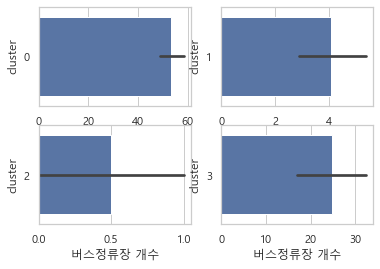

In [275]:
fig, ax = plt.subplots(ncols=2, nrows=2)

sns.barplot(data=df0,y='cluster',x='버스정류장 개수',orient='h', ax=ax[0,0]) #클러스터1
sns.barplot(data=df1,y='cluster',x='버스정류장 개수',orient='h', ax=ax[0,1]) #클러스터2
sns.barplot(data=df2,y='cluster',x='버스정류장 개수',orient='h', ax=ax[1,0]) #클러스터3
sns.barplot(data=df3,y='cluster',x='버스정류장 개수',orient='h', ax=ax[1,1]) #클러스터4

### 차이를 보인 컬럼

...

# 상관관계

In [22]:
data_S = pd.read_csv('최종_분석데이터.csv',encoding='cp949')
data_S

,grid,도시재생사업수,대중교통,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
0,1,2,0.000000,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
1,2,2,10007.452250,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
2,3,2,9824.109813,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
3,4,2,32.558804,101.626016,0.000936,54159.49191,21,40,51.123292,3778295.345,195318.1818,3647355.980
4,5,2,0.000000,101.626016,0.000936,54159.49191,21,40,0.000000,4099760.252,194850.0000,4051100.935
...,...,...,...,...,...,...,...,...,...,...,...,...
33446,75000,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33447,75001,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33448,75002,0,2306.248398,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563
33449,75003,0,0.000000,1032.258065,0.002861,98420.37476,21,39,13.779205,1208408.352,436105.8824,1194059.563


In [23]:
data_S.columns

Index(['grid', '도시재생사업수', '대중교통', '기초수급자_인구밀도', '저소득층_비율', '총생활인구', '초미세먼지',
       '미세먼지', '인당녹지면적', '토지공시지가평균', '임야공시지가평균', '총공시지가평균'],
      dtype='object')

In [24]:
data_S.corr()

,grid,도시재생사업수,대중교통,기초수급자_인구밀도,저소득층_비율,총생활인구,초미세먼지,미세먼지,인당녹지면적,토지공시지가평균,임야공시지가평균,총공시지가평균
grid,1.000000,-0.261751,0.016925,0.020295,0.138727,0.232032,0.079303,0.012546,0.007465,0.187888,0.057178,0.176284
도시재생사업수,-0.261751,1.000000,-0.023543,-0.069857,-0.002287,0.139093,0.002868,-0.023159,0.056744,-0.067048,-0.058976,-0.067669
대중교통,0.016925,-0.023543,1.000000,0.144725,-0.028711,-0.010085,0.014372,-0.004260,-0.047516,0.179342,0.107012,0.185730
기초수급자_인구밀도,0.020295,-0.069857,0.144725,1.000000,0.186464,-0.093622,0.092895,0.070242,-0.091159,-0.109104,0.024759,-0.100429
저소득층_비율,0.138727,-0.002287,-0.028711,0.186464,1.000000,0.611562,0.141957,-0.201203,-0.047812,-0.102606,-0.038804,-0.106452
총생활인구,0.232032,0.139093,-0.010085,-0.093622,0.611562,1.000000,0.141650,-0.081554,0.066436,0.236596,-0.038388,0.230655
초미세먼지,0.079303,0.002868,0.014372,0.092895,0.141957,0.141650,1.000000,0.389777,0.101937,-0.079737,-0.048885,-0.081851
미세먼지,0.012546,-0.023159,-0.004260,0.070242,-0.201203,-0.081554,0.389777,1.000000,0.156550,-0.050620,0.027743,-0.049767
인당녹지면적,0.007465,0.056744,-0.047516,-0.091159,-0.047812,0.066436,0.101937,0.156550,1.000000,-0.054606,-0.049006,-0.057153
토지공시지가평균,0.187888,-0.067048,0.179342,-0.109104,-0.102606,0.236596,-0.079737,-0.050620,-0.054606,1.000000,0.143552,0.999230


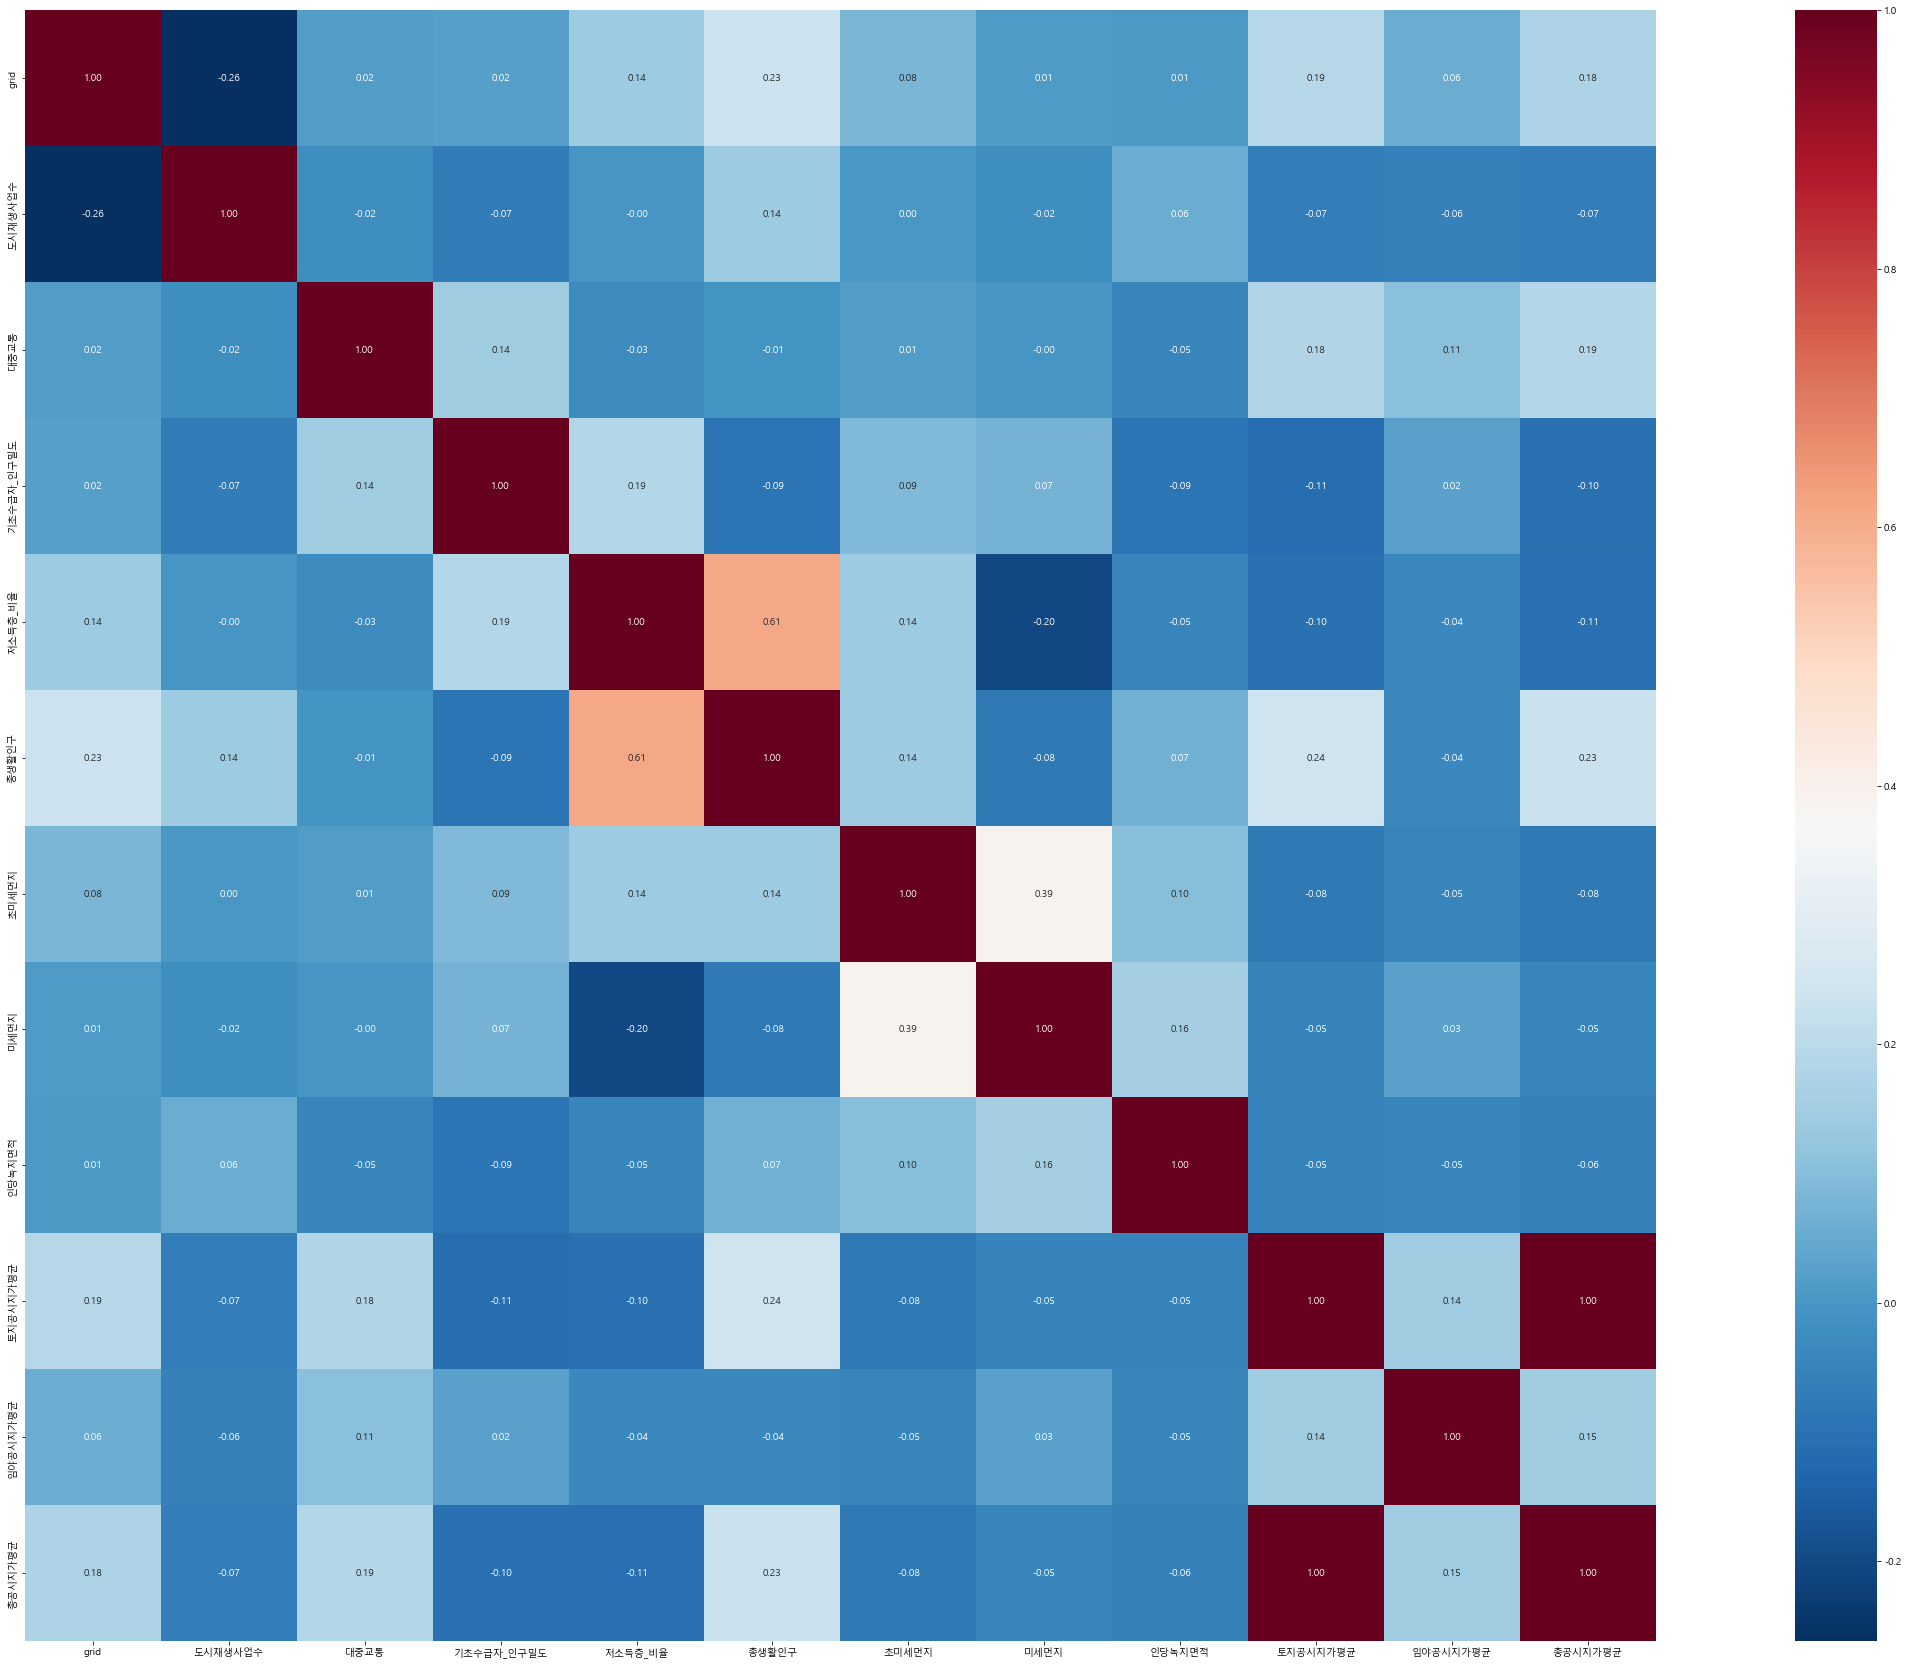

In [25]:
fig=plt.gcf()
fig.set_size_inches(50,30)
hm=sns.heatmap(data_S.corr(), cmap='RdBu_r', square=True, cbar=True, annot=True, fmt=".2f")

In [26]:
hm.get_figure().savefig("상관관계.png")